# Stored restriction maps visualisations

## 1. Import an Functions

In [110]:
import os
import torch
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats

In [111]:
def fbc(L):
    l=L.shape[0]
    B=L.copy()
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])

    F=L-B
    return B , F

## 2. Data Manipulation: Load Laplacian and compute curvatures 

In [112]:
stalk_dim = 1
hidden_channels = 16
dataset = "texas"
layers = 2
epochs = 500

# store node features if needed
#with open(f"../datasets/{dataset}/raw/out1_node_feature_label.txt", "r") as f:
    # for line in f:
    #     print(line.strip())
    # df_node_feature = pd.read_csv(f"../datasets/{dataset}/raw/out1_node_feature_label.txt", sep="\t")

MAPS, LAPLACIANS = [], []
for layer in range(layers):
    map_path = f"../results/maps/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold7_seed43.pt"
    lap_path = f"../results/laplacians/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold7_seed43.pt"
    MAPS.append(torch.load(map_path))
    LAPLACIANS.append(torch.load(lap_path))

DF = []
for maps in MAPS:
    df = pd.DataFrame(maps.cpu().tolist(), columns=["source", "target", "map_value"])
    df[["source", "target"]] = df[["source", "target"]].astype(int)
    df.sort_values(by=["source", "target"], ascending=[True, True], inplace=True)
    DF.append(df)   

DF_Lap = []
for laplacian in LAPLACIANS:
    df = pd.DataFrame(laplacian.cpu().tolist())
    DF_Lap.append(df)

In [113]:
L0_LIST = []
L0_LIST_DF = []

for df in DF_Lap:

    df = df.transpose().copy()
    # display(df)
    df.rename(columns={0: "source", 1: "target", 2: "value"}, inplace=True)
    df_new = df.pivot(index="source", columns="target", values="value").fillna(0)
    L0 = df_new.to_numpy()
    #display(L0)
    
    L0_LIST_DF.append(df_new)
    L0_LIST.append(L0)

In [114]:
L0_LIST_DF[0]

target,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,173.0,174.0,175.0,176.0,177.0,178.0,179.0,180.0,181.0,182.0
source,,,,,,,,,,,,,,,,,,,,,
0.0,0.342037,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1.0,0.000000,0.172557,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2.0,0.000000,0.000000,0.228309,0.000000,0.000000,0.0,0.0,0.0,-0.206521,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
3.0,0.000000,0.000000,0.000000,0.258451,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
4.0,0.000000,0.000000,0.000000,0.000000,0.475706,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.379056,0.000000,0.000000,0.000000,0.000000
179.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.246621,0.000000,0.000000,0.000000
180.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.432225,0.000000,0.000000


In [115]:
# primer for Weber Ricci edge-curvature

weights_list = []
edge_keys_list = []

for L0 in L0_LIST:
    canonical = {}

    rows, cols = np.where(L0 != 0)

    for i, j in zip(rows, cols):
        key = (min(i, j), max(i, j))   # enforce i <= j
        value = 1 if i == j else abs(L0[i, j])

        if key in canonical:
            if not np.isclose(canonical[key], value):
                print(f"Warning: mismatch at {key}: {canonical[key]} vs {value}")
        else:
            canonical[key] = value

    ordered_items = sorted(canonical.items())   # lexicographic order by key

    edge_keys = [k for k, v in ordered_items]
    weights = [v for k, v in ordered_items]

    edge_keys_list.append(edge_keys)
    weights_list.append(weights)

In [116]:
display(edge_keys_list[0])
display(weights_list[0])

[(np.int64(0), np.int64(0)),
 (np.int64(0), np.int64(58)),
 (np.int64(0), np.int64(121)),
 (np.int64(1), np.int64(1)),
 (np.int64(1), np.int64(80)),
 (np.int64(2), np.int64(2)),
 (np.int64(2), np.int64(8)),
 (np.int64(3), np.int64(3)),
 (np.int64(3), np.int64(56)),
 (np.int64(4), np.int64(4)),
 (np.int64(4), np.int64(66)),
 (np.int64(4), np.int64(146)),
 (np.int64(4), np.int64(164)),
 (np.int64(5), np.int64(5)),
 (np.int64(5), np.int64(20)),
 (np.int64(5), np.int64(56)),
 (np.int64(5), np.int64(101)),
 (np.int64(6), np.int64(6)),
 (np.int64(6), np.int64(56)),
 (np.int64(6), np.int64(171)),
 (np.int64(7), np.int64(7)),
 (np.int64(7), np.int64(14)),
 (np.int64(7), np.int64(34)),
 (np.int64(8), np.int64(8)),
 (np.int64(8), np.int64(173)),
 (np.int64(9), np.int64(9)),
 (np.int64(9), np.int64(56)),
 (np.int64(9), np.int64(106)),
 (np.int64(10), np.int64(10)),
 (np.int64(10), np.int64(108)),
 (np.int64(11), np.int64(11)),
 (np.int64(11), np.int64(56)),
 (np.int64(11), np.int64(94)),
 (np.int

[1,
 np.float64(0.11863920837640762),
 np.float64(0.17844362556934357),
 1,
 np.float64(0.13917860388755798),
 1,
 np.float64(0.20652072131633759),
 1,
 np.float64(0.05190189555287361),
 1,
 np.float64(0.09464220702648163),
 np.float64(0.1325199156999588),
 np.float64(0.15839195251464844),
 1,
 np.float64(0.1451467126607895),
 np.float64(0.04127955809235573),
 np.float64(0.17683975398540497),
 1,
 np.float64(0.03397294878959656),
 np.float64(0.12391416728496552),
 1,
 np.float64(0.16725780069828033),
 np.float64(0.11000427603721619),
 1,
 np.float64(0.12958838045597076),
 1,
 np.float64(0.036732230335474014),
 np.float64(0.2009141594171524),
 1,
 np.float64(0.18386083841323853),
 1,
 np.float64(0.04161423444747925),
 np.float64(0.1658560335636139),
 np.float64(0.1343647688627243),
 1,
 np.float64(0.0485922247171402),
 1,
 np.float64(0.14263315498828888),
 1,
 1,
 np.float64(0.08540774881839752),
 np.float64(0.09351703524589539),
 np.float64(0.11519212275743484),
 np.float64(0.074729569

In [117]:
import numpy as np
from collections import defaultdict

# Weighted Forman-Ricci edge curvature
# Assumptions:
#   - L0 is symmetric
#   - off-diagonal nonzero entries define undirected edges
#   - edge weight w(i,j) = abs(L0[i,j])
#   - vertex weights w(v) = 1.0

ricci_dict_list = []
edge_weight_dict_list = []

for L0 in L0_LIST:
    n = L0.shape[0]

    # --------------------------------------------------
    # Step 1: build canonical undirected edge-weight dict
    # --------------------------------------------------
    edge_weights = {}
    rows, cols = np.where(L0 != 0)

    for i, j in zip(rows, cols):
        if i == j:
            continue  # diagonals are not graph edges for edge-curvature
        key = (min(i, j), max(i, j))
        val = abs(L0[i, j])

        if key in edge_weights:
            if not np.isclose(edge_weights[key], val):
                print(f"Warning: mismatch at edge {key}: {edge_weights[key]} vs {val}")
        else:
            edge_weights[key] = val

    # lexicographic order
    edge_weights = dict(sorted(edge_weights.items()))
    edge_weight_dict_list.append(edge_weights)

    # --------------------------------------------------
    # Step 2: adjacency of edges around each vertex
    # --------------------------------------------------
    incident_edges = defaultdict(list)
    for (u, v), w_e in edge_weights.items():
        incident_edges[u].append((u, v))
        incident_edges[v].append((u, v))

    # --------------------------------------------------
    # Step 3: compute weighted Forman-Ricci curvature
    # --------------------------------------------------
    ricci_dict = {}
    vertex_weight = np.ones(n)  # omega(v)=1

    for (u, v), w_e in edge_weights.items():
        wu = vertex_weight[u]
        wv = vertex_weight[v]

        # first term
        curvature = w_e * (wu / w_e + wv / w_e)

        # contribution from edges parallel/adjacent through u
        for e_u in incident_edges[u]:
            if e_u == (u, v):
                continue
            w_eu = edge_weights[e_u]
            curvature -= w_e * (wu / np.sqrt(w_e * w_eu))

        # contribution from edges parallel/adjacent through v
        for e_v in incident_edges[v]:
            if e_v == (u, v):
                continue
            w_ev = edge_weights[e_v]
            curvature -= w_e * (wv / np.sqrt(w_e * w_ev))

        ricci_dict[(u, v)] = curvature

    ricci_dict_list.append(dict(sorted(ricci_dict.items())))

In [118]:
min(ricci_dict_list[0].values())

np.float64(-123.22015168372518)

In [119]:
import numpy as np
from collections import defaultdict

# Weighted Forman-Ricci edge curvature
# Assumptions:
#   - L0 is symmetric
#   - off-diagonal nonzero entries define undirected edges
#   - edge weight w(i,j) = abs(L0[i,j])
#   - vertex weights w(v) = degree(v)

ricci_dict_list_vertex_degree = []
edge_weight_dict_list = []
vertex_weight_list = []

for L0 in L0_LIST:
    n = L0.shape[0]

    # --------------------------------------------------
    # Step 1: build canonical undirected edge-weight dict
    # --------------------------------------------------
    edge_weights = {}
    rows, cols = np.where(L0 != 0)

    for i, j in zip(rows, cols):
        if i == j:
            continue  # diagonals are not graph edges for edge-curvature
        key = (min(i, j), max(i, j))
        val = abs(L0[i, j])

        if key in edge_weights:
            if not np.isclose(edge_weights[key], val):
                print(f"Warning: mismatch at edge {key}: {edge_weights[key]} vs {val}")
        else:
            edge_weights[key] = val

    # lexicographic order
    edge_weights = dict(sorted(edge_weights.items()))
    edge_weight_dict_list.append(edge_weights)

    # --------------------------------------------------
    # Step 2: adjacency of edges around each vertex
    # --------------------------------------------------
    incident_edges = defaultdict(list)
    for (u, v), w_e in edge_weights.items():
        incident_edges[u].append((u, v))
        incident_edges[v].append((u, v))

    # --------------------------------------------------
    # Step 2.5: vertex weights = node degrees
    # --------------------------------------------------
    vertex_weight = np.zeros(n, dtype=float)
    for v in range(n):
        vertex_weight[v] = len(incident_edges[v])

    vertex_weight_list.append(vertex_weight.copy())

    # --------------------------------------------------
    # Step 3: compute weighted Forman-Ricci curvature
    # --------------------------------------------------
    ricci_dict = {}

    for (u, v), w_e in edge_weights.items():
        wu = vertex_weight[u]
        wv = vertex_weight[v]

        # first term
        curvature = w_e * (wu / w_e + wv / w_e)

        # contribution from edges adjacent through u
        for e_u in incident_edges[u]:
            if e_u == (u, v):
                continue
            w_eu = edge_weights[e_u]
            curvature -= w_e * (wu / np.sqrt(w_e * w_eu))

        # contribution from edges adjacent through v
        for e_v in incident_edges[v]:
            if e_v == (u, v):
                continue
            w_ev = edge_weights[e_v]
            curvature -= w_e * (wv / np.sqrt(w_e * w_ev))

        ricci_dict[(u, v)] = curvature

    ricci_dict_list_vertex_degree.append(dict(sorted(ricci_dict.items())))

In [120]:
import numpy as np
from collections import defaultdict

ricci_dict_list_standard_weights = []
edge_weight_dict_list = []
vertex_weight_list = []

for L0 in L0_LIST:
    n = L0.shape[0]

    # --------------------------------------------------
    # Step 1: build canonical undirected edge-weight dict
    # --------------------------------------------------
    edge_weights = {}
    rows, cols = np.where(L0 != 0)

    for i, j in zip(rows, cols):
        if i == j:
            continue
        key = (min(i, j), max(i, j))
        val = abs(L0[i, j])

        if key in edge_weights:
            if not np.isclose(edge_weights[key], val):
                print(f"Warning: mismatch at edge {key}")
        else:
            edge_weights[key] = val

    edge_weights = dict(sorted(edge_weights.items()))
    edge_weight_dict_list.append(edge_weights)

    # --------------------------------------------------
    # Step 2: adjacency
    # --------------------------------------------------
    incident_edges = defaultdict(list)
    for (u, v) in edge_weights:
        incident_edges[u].append((u, v))
        incident_edges[v].append((u, v))

    # --------------------------------------------------
    # Step 2.5: vertex weights = |L_ii|
    # --------------------------------------------------
    vertex_weight = np.abs(np.diag(L0)).astype(float)
    vertex_weight_list.append(vertex_weight.copy())

    # --------------------------------------------------
    # Step 3: curvature
    # --------------------------------------------------
    ricci_dict = {}

    for (u, v), w_e in edge_weights.items():
        wu = vertex_weight[u]
        wv = vertex_weight[v]

        # simplified first term
        curvature = wu + wv

        for e_u in incident_edges[u]:
            if e_u == (u, v):
                continue
            w_eu = edge_weights[e_u]
            curvature -= w_e * (wu / np.sqrt(w_e * w_eu))

        for e_v in incident_edges[v]:
            if e_v == (u, v):
                continue
            w_ev = edge_weights[e_v]
            curvature -= w_e * (wv / np.sqrt(w_e * w_ev))

        ricci_dict[(u, v)] = curvature

    ricci_dict_list_standard_weights.append(dict(sorted(ricci_dict.items())))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib import cm, colors

# ------------------------------------------------------------
# Inputs assumed available:
#   ricci_dict_list[k]       = {(i, j): curvature, ...}
#   edge_weight_dict_list[k] = {(i, j): weight, ...}
# Optional:
#   pos = precomputed node positions dict {node: (x,y)}
# ------------------------------------------------------------

def plot_curvature_and_weights_per_layer(
    ricci_dict_list,
    edge_weight_dict_list,
    pos=None,
    layout_seed=42,
    node_size=7,
    figsize_per_layer=(12, 5),
    cmap_curv="coolwarm",
    cmap_w="viridis",
):
    n_layers = len(ricci_dict_list)
    assert n_layers == len(edge_weight_dict_list), "Lists must have same length"

    for layer in range(n_layers):
        ricci_dict = ricci_dict_list[layer]
        weight_dict = edge_weight_dict_list[layer]

        # Build graph from weights
        G = nx.Graph()
        for (u, v), w in weight_dict.items():
            G.add_edge(u, v, weight=w)

        if G.number_of_nodes() == 0:
            print(f"Layer {layer}: empty graph, skipping.")
            continue

        # Stable edge order
        edges = sorted(G.edges())
        nodes = sorted(G.nodes())

        # Positions
        if pos is None:
            layer_pos = nx.spring_layout(G, seed=layout_seed)
        else:
            layer_pos = pos

        # Values aligned with edge order
        curvature_vals = np.array([ricci_dict.get(tuple(sorted(e)), np.nan) for e in edges], dtype=float)
        weight_vals = np.array([weight_dict.get(tuple(sorted(e)), np.nan) for e in edges], dtype=float)

        # Color norms
        # Curvature: centered at 0 if possible
        finite_curv = curvature_vals[np.isfinite(curvature_vals)]

        if len(finite_curv) > 0:
            vmin = np.min(finite_curv)
            vmax = np.max(finite_curv)

            # avoid degenerate case
            if np.isclose(vmin, vmax):
                vmax = vmin + 1e-12

            norm_curv = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm_curv = colors.Normalize(vmin=-1, vmax=1)
        finite_w = weight_vals[np.isfinite(weight_vals)]
        if len(finite_w) > 0:
            wmin, wmax = np.nanmin(finite_w), np.nanmax(finite_w)
            if np.isclose(wmin, wmax):
                wmax = wmin + 1e-12
            norm_w = colors.Normalize(vmin=wmin, vmax=wmax)
        else:
            norm_w = colors.Normalize(vmin=0, vmax=1)

        fig, axes = plt.subplots(1, 2, figsize=figsize_per_layer)
        ax1, ax2 = axes

        # ---------------- Left: curvature ----------------
        nx.draw_networkx_nodes(
            G, layer_pos, nodelist=nodes, node_size=node_size, node_color="black", ax=ax1, alpha=0.5
        )
        nx.draw_networkx_edges(
            G,
            layer_pos,
            edgelist=edges,
            edge_color=curvature_vals,
            edge_cmap=cm.get_cmap(cmap_curv),
            edge_vmin=norm_curv.vmin,
            edge_vmax=norm_curv.vmax,
            width=1,
            ax=ax1,
        )
        ax1.set_title(f"Layer {layer} — Forman Ricci curvature")
        ax1.axis("off")

        sm1 = cm.ScalarMappable(norm=norm_curv, cmap=cm.get_cmap(cmap_curv))
        sm1.set_array([])
        cbar1 = fig.colorbar(sm1, ax=ax1, fraction=0.046, pad=0.04)
        cbar1.set_label("Curvature")

        # ---------------- Right: weights ----------------
        nx.draw_networkx_nodes(
            G, layer_pos, nodelist=nodes, node_size=node_size, node_color="black", ax=ax2, alpha=0.5
        )
        nx.draw_networkx_edges(
            G,
            layer_pos,
            edgelist=edges,
            edge_color=weight_vals,
            edge_cmap=cm.get_cmap(cmap_w),
            edge_vmin=norm_w.vmin,
            edge_vmax=norm_w.vmax,
            width=1,
            ax=ax2,
        )
        ax2.set_title(f"Layer {layer} — Edge weights")
        ax2.axis("off")

        sm2 = cm.ScalarMappable(norm=norm_w, cmap=cm.get_cmap(cmap_w))
        sm2.set_array([])
        cbar2 = fig.colorbar(sm2, ax=ax2, fraction=0.046, pad=0.04)
        cbar2.set_label("Weight")

        plt.suptitle(f"Layer {layer} — Unitary Nodes Weights", fontsize=16)

        plt.tight_layout()
        plt.show()

        # plt.savefig(f"./layer_{layer}_curvature_weights_unitary.png", dpi=300)

/var/folders/y1/h7g49sfs2z7g4fgb8v4c1bgc0000gn/T/ipykernel_20407/767728827.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  edge_cmap=cm.get_cmap(cmap_curv),
/var/folders/y1/h7g49sfs2z7g4fgb8v4c1bgc0000gn/T/ipykernel_20407/767728827.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sm1 = cm.ScalarMappable(norm=norm_curv, cmap=cm.get_cmap(cmap_curv))
/var/folders/y1/h7g49sfs2z7g4fgb8v4c1bgc0000gn/T/ipykernel_20407/767728827.py:113: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.ge

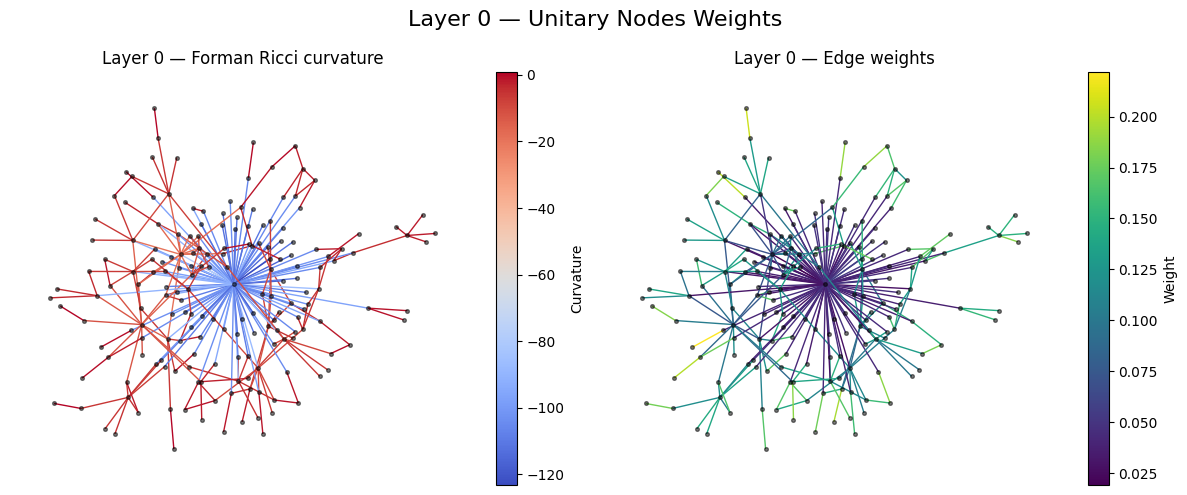

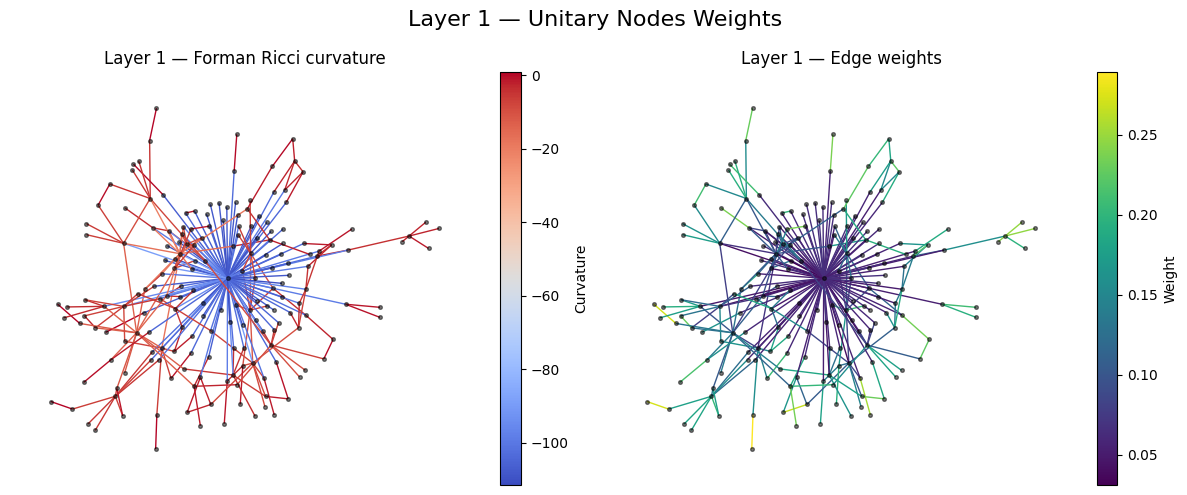

In [132]:
plot_curvature_and_weights_per_layer(
    ricci_dict_list,
    edge_weight_dict_list,
)

In [123]:
B_list = []

for df in DF:

    df = df.copy()
    df[["source", "target"]] = df[["source", "target"]].astype(int)

    # signed value
    df["signed_map"] = np.where(df["target"] < df["source"], df["map_value"], -df["map_value"])

    # canonical undirected edge label
    df["edge"] = df.apply(lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])),axis=1)

    # build node-by-edge matrix
    nodes = sorted(set(df["source"]).union(df["target"]))
    edges = sorted(df["edge"].unique())

    B = df.pivot(index="source", columns="edge", values="signed_map")
    B = B.reindex(index=nodes, columns=edges, fill_value=0)

    B.fillna(0, inplace=True)
    B_np = B.to_numpy(dtype=float)

    B_list.append(B)

EDGE_LIST = []
NODE_LIST = []

for B in B_list:
    EDGE_LIST.append(list(B.columns))
    NODE_LIST.append(B.index.tolist())

In [ ]:
# G = nx.Graph()
# G.add_nodes_from(B.index)
# G.add_edges_from(list(B.columns))

## 3. Plotting Weights

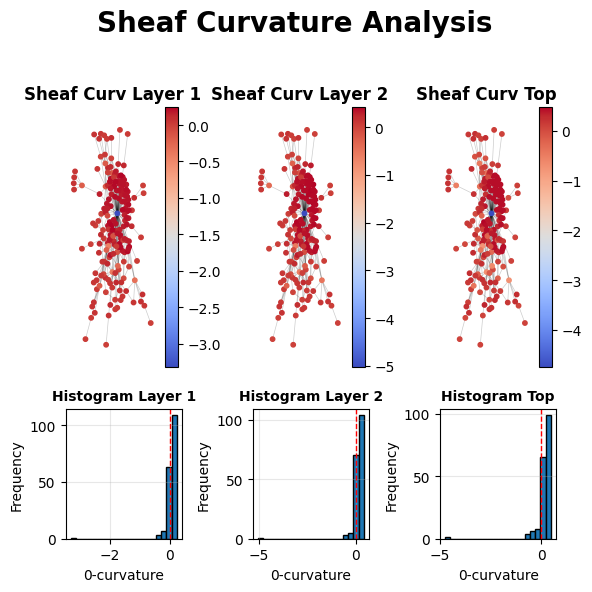

In [ ]:
# pos_use = nx.spring_layout(G, seed=42)
# cmap    = plt.cm.coolwarm

# fig, ax = plt.subplots(2, layers + 1, figsize=(2*(layers + 1), 6),
#                        gridspec_kw={"height_ratios": [3, 1.5]})

# # ---------- One column per layer ----------
# for layer in range(layers):
#     curvatures = np.asarray(f0_list[layer])
#     norm       = plt.Normalize(vmin=curvatures.min(), vmax=curvatures.max())

#     nx.draw_networkx_nodes(G, pos_use, ax=ax[0, layer], node_size=10, node_color=cmap(norm(curvatures)))
#     nx.draw_networkx_edges(G, pos_use, ax=ax[0, layer], width=0.5, alpha=0.2)
#     plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax[0, layer])
#     ax[0, layer].set_title(f"Sheaf Curv Layer {layer+1}", fontweight="bold", fontsize=12)
#     ax[0, layer].axis("off")

#     ax[1, layer].hist(curvatures, bins=20, edgecolor="black")
#     ax[1, layer].axvline(0, color="red", linestyle="--", linewidth=1)
#     ax[1, layer].set_title(f"Histogram Layer {layer+1}", fontsize=10, fontweight="bold")
#     ax[1, layer].set_xlabel("0-curvature")
#     ax[1, layer].set_ylabel("Frequency")
#     ax[1, layer].grid(alpha=0.3)

# # ---------- Last column: f0_top ----------
# f0_top_arr = np.asarray(f0_top)
# norm       = plt.Normalize(vmin=f0_top_arr.min(), vmax=f0_top_arr.max())

# nx.draw_networkx_nodes(G, pos_use, ax=ax[0, layers], node_size=10, node_color=cmap(norm(f0_top_arr)))
# nx.draw_networkx_edges(G, pos_use, ax=ax[0, layers], width=0.5, alpha=0.2)
# plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax[0, layers])
# ax[0, layers].set_title("Sheaf Curv Top", fontweight="bold", fontsize=12)
# ax[0, layers].axis("off")

# ax[1, layers].hist(f0_top_arr, bins=20, edgecolor="black")
# ax[1, layers].axvline(0, color="red", linestyle="--", linewidth=1)
# ax[1, layers].set_title("Histogram Top", fontsize=10, fontweight="bold")
# ax[1, layers].set_xlabel("0-curvature")
# ax[1, layers].set_ylabel("Frequency")
# ax[1, layers].grid(alpha=0.3)

# fig.suptitle("Sheaf Curvature Analysis", fontsize=20, fontweight="bold")
# fig.tight_layout(rect=[0, 0, 1, 0.95])
# plt.show()